In [25]:
from datetime import datetime
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

In [26]:
# Path to the JSON files
data_dir = Path('/Users/veikka/thesis-work/scraping/output_data/')

# Get all JSON files
json_files = list(data_dir.glob('*.json'))

print(f"Found {len(json_files)} JSON files")

# Load and concatenate all JSON files
all_data = []
for json_file in json_files:
    with open(json_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
        # Each JSON file contains a list of records
        all_data.extend(data)

# Create a single dataframe
df = pd.DataFrame(all_data)

print(f"Total records: {len(df)}")
print(f"\nDataFrame shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Found 357 JSON files
Total records: 550813

DataFrame shape: (550813, 9)

Columns: ['id', 'author_id', 'message', 'date_time', 'engagement', 'forum', 'url', 'company_name', 'ticker']

First few rows:


,id,author_id,message,date_time,engagement,forum,url,company_name,ticker
0,Sijoitustieto.comment-17873,Sijoitustieto.Unknown,Juha kirjoitti:\n\nAdmicom Oyj:n anti ylimerki...,2018-02-02T04:25:00,N/A,Sijoitustieto,https://www.sijoitustieto.fi/sijoituskeskustel...,Admicom,ADMCM
1,Sijoitustieto.comment-17885,Sijoitustieto.Unknown,Kiitos luottamuksesta Aki! Sijoitustiedon kesk...,2018-02-02T13:29:00,N/A,Sijoitustieto,https://www.sijoitustieto.fi/sijoituskeskustel...,Admicom,ADMCM
2,Sijoitustieto.comment-17889,Sijoitustieto.Unknown,Itselläni ollut käteisvarat vähän tavallista t...,2018-02-02T14:44:00,N/A,Sijoitustieto,https://www.sijoitustieto.fi/sijoituskeskustel...,Admicom,ADMCM
3,Sijoitustieto.comment-17941,Sijoitustieto.Unknown,"Oma veikkaus on, että yleisöannissa kaikki saa...",2018-02-04T17:16:00,N/A,Sijoitustieto,https://www.sijoitustieto.fi/sijoituskeskustel...,Admicom,ADMCM
4,Sijoitustieto.comment-17960,Sijoitustieto.Unknown,"Googlen hakuanalyysi piti kutinsa, mutta olisi...",2018-02-05T14:33:00,N/A,Sijoitustieto,https://www.sijoitustieto.fi/sijoituskeskustel...,Admicom,ADMCM


In [27]:
# Set up matplotlib style
plt.style.use('default')
%matplotlib inline

## Data Preprocessing

First, we'll clean the data by removing noise and filtering based on quality criteria.

In [28]:
import re

# Store original count
original_count = len(df)
print(f"Starting with {original_count:,} records")

# 1. Convert date_time to datetime and remove timezone offset
df['date_time'] = pd.to_datetime(df['date_time'], format='mixed', utc=True)
# Convert to timezone-naive by removing the timezone info
df['date_time'] = df['date_time'].dt.tz_localize(None)

# 2. Remove posts before 2012-01-01
cutoff_date = pd.Timestamp('2012-01-01')
df = df[df['date_time'] >= cutoff_date].copy()
print(f"After removing posts before 2012-01-01: {len(df):,} records ({len(df)/original_count*100:.1f}% remaining)")

# 3. Remove URLs and HTML tags (keeping \n characters)
def clean_text(text):
    if pd.isna(text):
        return text
    # Remove URLs (http, https, www)
    text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
    text = re.sub(r'www\.(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    # Clean up extra whitespace (but preserve \n)
    text = re.sub(r'[ \t]+', ' ', text)
    text = text.strip()
    return text

df['message'] = df['message'].apply(clean_text)
print(f"After cleaning URLs/HTML: {len(df):,} records ({len(df)/original_count*100:.1f}% remaining)")

# 4. Remove posts with less than 20 characters
df = df[df['message'].str.len() >= 20].copy()
print(f"After removing messages < 20 chars: {len(df):,} records ({len(df)/original_count*100:.1f}% remaining)")

print(f"\n{'='*60}")
print(f"Total records removed: {original_count - len(df):,} ({(original_count - len(df))/original_count*100:.1f}%)")
print(f"Final record count: {len(df):,}")
print(f"{'='*60}")

Starting with 550,813 records
After removing posts before 2012-01-01: 548,986 records (99.7% remaining)
After cleaning URLs/HTML: 548,986 records (99.7% remaining)
After removing messages < 20 chars: 542,715 records (98.5% remaining)

Total records removed: 8,098 (1.5%)
Final record count: 542,715


In [29]:
# Show sample of cleaned messages
print("Sample cleaned messages:")
print("="*80)
for i, row in df.sample(6).iterrows():
    print(f"\nTicker: {row['ticker']}")
    print(f"\nForum: {row['forum']}")
    print(f"Date: {row['date_time']}")
    print(f"Message ({len(row['message'])} chars):")
    print(row['message'][:200] + "..." if len(row['message']) > 200 else row['message'])
    print("-"*80)

Sample cleaned messages:

Ticker: TITAN

Forum: Kauppalehti
Date: 2018-03-15 11:41:39
Message (195 chars):
Nojoo, samoin täällä. On Titaniumia, Nordeaa, Sampoa, JPMorgania, Taaleria... Mutta uskon itse alaan, toiminta tehostuu, sijoitustoiminnasta tulossa mainstreamia ja korkojen nousu jeesaa pankkeja
--------------------------------------------------------------------------------

Ticker: BITTI

Forum: Kauppalehti
Date: 2022-10-06 20:07:02
Message (99 chars):
Juippi65 sanoi:
Anteeksi Vittuutuntumiseni!

Ei mitään. Tapahtuu sitä näköjään pitkähermoisellekin.
--------------------------------------------------------------------------------

Ticker: OPTOMED

Forum: Inderes
Date: 2024-03-20 19:23:49.294000
Message (117 chars):
Selviääkö tuo asia vasta Helsingin pörssin sulkeutumisen jälkeen vai jo sen auki olo aikana,onko tästä mitään tietoa?
--------------------------------------------------------------------------------

Ticker: FSECURE

Forum: Kauppalehti
Date: 2016-06-02 06:28:12
Messa

## Exploratory Data Analysis

### 1. ID Column - Duplicate Check

In [30]:
# Check for duplicate IDs
total_ids = len(df['id'])
unique_ids = df['id'].nunique()
duplicate_count = total_ids - unique_ids

print(f"Total IDs: {total_ids:,}")
print(f"Unique IDs: {unique_ids:,}")
print(f"Duplicate IDs: {duplicate_count:,}")
print(f"Duplicate percentage: {(duplicate_count/total_ids)*100:.2f}%")

if duplicate_count > 0:
    print(f"\nSample duplicates:")
    duplicates = df[df.duplicated(subset=['id'], keep=False)].sort_values('id')
    print(duplicates[['id', 'company_name', 'ticker', 'date_time']].head(10))

Total IDs: 542,715
Unique IDs: 542,715
Duplicate IDs: 0
Duplicate percentage: 0.00%


### 2. Message Length Statistics

Message Length Statistics:
--------------------------------------------------
min                 : 20 characters
max                 : 32,176 characters
mean                : 495 characters
median              : 320 characters
mode                : 62 characters
25th percentile     : 160 characters
50th percentile     : 320 characters
75th percentile     : 610 characters
90th percentile     : 1,061 characters
99th percentile     : 2,880 characters


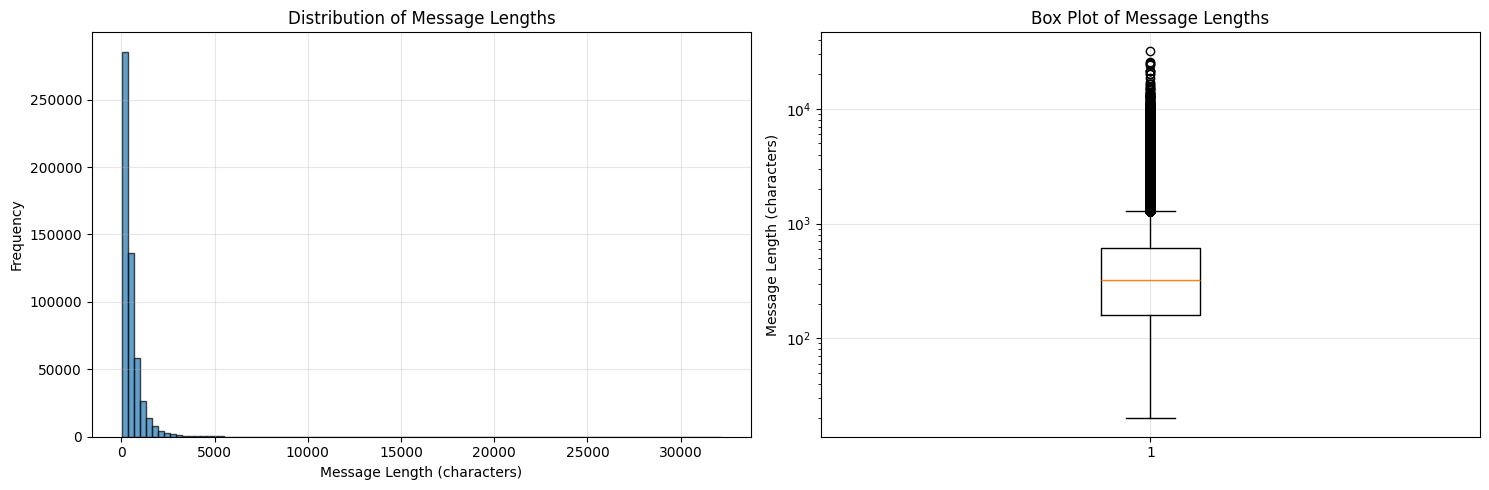

In [31]:
# Calculate message lengths
df['message_length'] = df['message'].str.len()

# Calculate statistics
msg_stats = {
    'min': df['message_length'].min(),
    'max': df['message_length'].max(),
    'mean': df['message_length'].mean(),
    'median': df['message_length'].median(),
    'mode': df['message_length'].mode()[0] if len(df['message_length'].mode()) > 0 else None,
    '25th percentile': df['message_length'].quantile(0.25),
    '50th percentile': df['message_length'].quantile(0.50),
    '75th percentile': df['message_length'].quantile(0.75),
    '90th percentile': df['message_length'].quantile(0.90),
    '99th percentile': df['message_length'].quantile(0.99),
}

print("Message Length Statistics:")
print("-" * 50)
for key, value in msg_stats.items():
    print(f"{key:20s}: {value:,.0f} characters")

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df['message_length'], bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Message Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Message Lengths')
axes[0].grid(True, alpha=0.3)

# Box plot (log scale for better visualization)
axes[1].boxplot(df['message_length'], vert=True)
axes[1].set_ylabel('Message Length (characters)')
axes[1].set_title('Box Plot of Message Lengths')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3. Date-Time Analysis

Date Range:
  Earliest message: 2012-01-02 07:38:11
  Latest message:   2025-12-18 07:42:36.068000
  Time span:        5099 days (14.0 years)


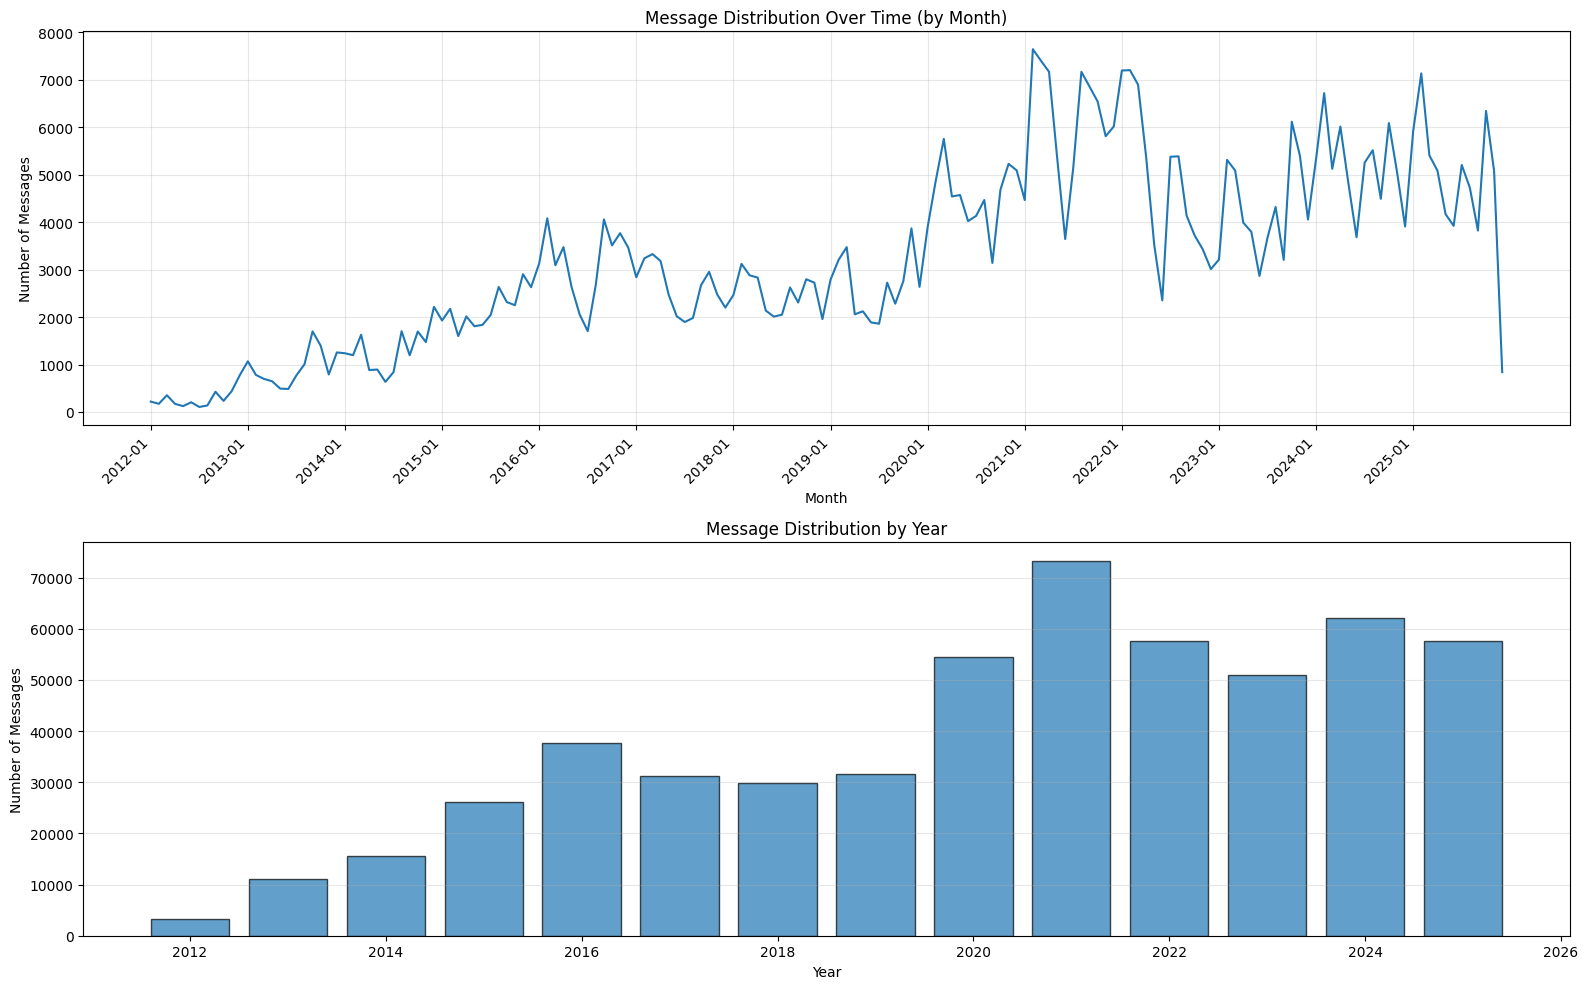


Top 10 Most Active Months:
    year_month  count
109    2021-02   7647
110    2021-03   7405
121    2022-02   7206
120    2022-01   7198
111    2021-04   7171
115    2021-08   7170
157    2025-02   7137
122    2022-03   6901
116    2021-09   6861
145    2024-02   6721


In [32]:
# Min and Max dates
min_date = df['date_time'].min()
max_date = df['date_time'].max()

print(f"Date Range:")
print(f"  Earliest message: {min_date}")
print(f"  Latest message:   {max_date}")
print(f"  Time span:        {(max_date - min_date).days} days ({(max_date - min_date).days/365.25:.1f} years)")

# Extract year-month for grouping
df['year_month'] = df['date_time'].dt.to_period('M')

# Count messages by month
monthly_counts = df.groupby('year_month').size().reset_index(name='count')
monthly_counts['year_month'] = monthly_counts['year_month'].astype(str)

# Plot distribution by month
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Time series plot
axes[0].plot(range(len(monthly_counts)), monthly_counts['count'], linewidth=1.5)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Messages')
axes[0].set_title('Message Distribution Over Time (by Month)')
axes[0].grid(True, alpha=0.3)
# Show every 12th label (yearly)
tick_positions = range(0, len(monthly_counts), 12)
axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels([monthly_counts['year_month'].iloc[i] if i < len(monthly_counts) else '' 
                          for i in tick_positions], rotation=45, ha='right')

# Histogram by year
df['year'] = df['date_time'].dt.year
yearly_counts = df.groupby('year').size()
axes[1].bar(yearly_counts.index, yearly_counts.values, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Messages')
axes[1].set_title('Message Distribution by Year')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nTop 10 Most Active Months:")
print(monthly_counts.sort_values('count', ascending=False).head(10))

### 4. Engagement Analysis

Engagement Statistics:
  Non-null values: 542,715 (100.00%)
  Null values:     0 (0.00%)

Top 10 Most Common Engagement Values:
   1. 'N/A': 349,278 occurrences (64.36%)
   2. '1': 13,280 occurrences (2.45%)
   3. '0': 12,937 occurrences (2.38%)
   4. '2': 11,622 occurrences (2.14%)
   5. '3': 10,025 occurrences (1.85%)
   6. '4': 8,622 occurrences (1.59%)
   7. '5': 7,445 occurrences (1.37%)
   8. '6': 6,500 occurrences (1.20%)
   9. '7': 5,586 occurrences (1.03%)
  10. '8': 4,912 occurrences (0.91%)


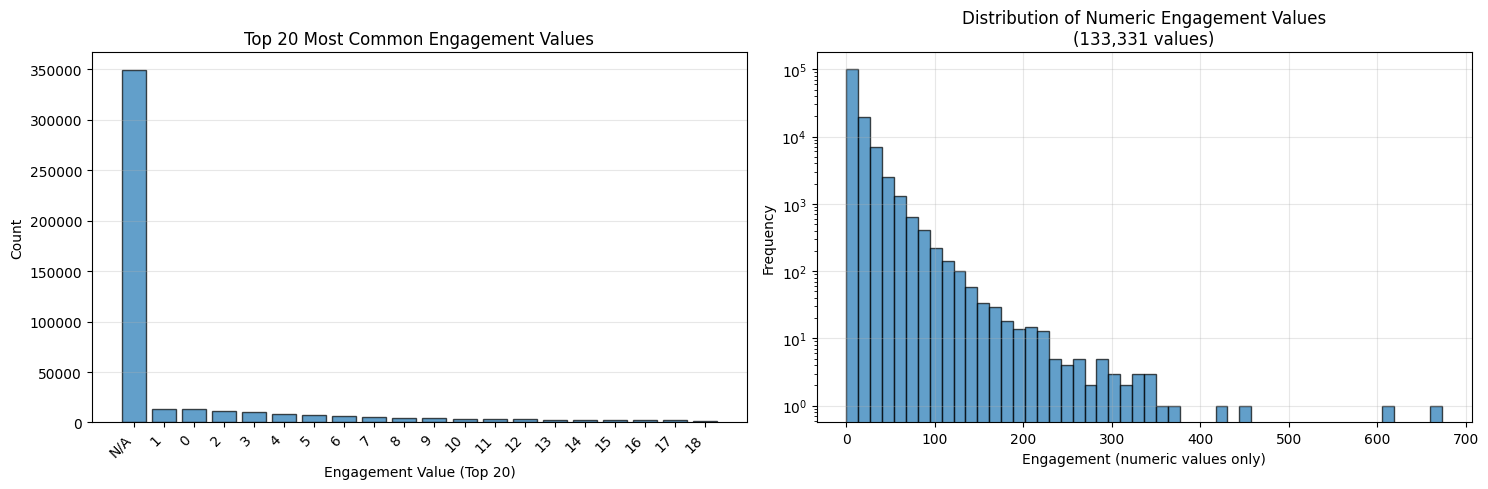

In [33]:
# Engagement analysis
non_null_engagement = df['engagement'].notna().sum()
total_engagement = len(df)

print(f"Engagement Statistics:")
print(f"  Non-null values: {non_null_engagement:,} ({non_null_engagement/total_engagement*100:.2f}%)")
print(f"  Null values:     {total_engagement - non_null_engagement:,} ({(total_engagement - non_null_engagement)/total_engagement*100:.2f}%)")

# Top 10 most common engagement values
print(f"\nTop 10 Most Common Engagement Values:")
top_engagement = df['engagement'].value_counts().head(10)
for idx, (value, count) in enumerate(top_engagement.items(), 1):
    print(f"  {idx:2d}. '{value}': {count:,} occurrences ({count/total_engagement*100:.2f}%)")

# Plot engagement distribution (for numeric convertible values)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart of top 20 values
top_20 = df['engagement'].value_counts().head(20)
axes[0].bar(range(len(top_20)), top_20.values, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Engagement Value (Top 20)')
axes[0].set_ylabel('Count')
axes[0].set_title('Top 20 Most Common Engagement Values')
axes[0].set_xticks(range(len(top_20)))
axes[0].set_xticklabels(top_20.index, rotation=45, ha='right')
axes[0].grid(True, alpha=0.3, axis='y')

# Try to convert to numeric for distribution plot
df['engagement_numeric'] = pd.to_numeric(df['engagement'], errors='coerce')
numeric_engagement = df['engagement_numeric'].dropna()

if len(numeric_engagement) > 0:
    axes[1].hist(numeric_engagement, bins=50, edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Engagement (numeric values only)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'Distribution of Numeric Engagement Values\n({len(numeric_engagement):,} values)')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_yscale('log')
else:
    axes[1].text(0.5, 0.5, 'No numeric engagement values found', 
                 ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

### 5. Ticker Analysis

In [34]:
# Ticker analysis
unique_tickers = df['ticker'].nunique()
total_messages = len(df)

print(f"Ticker Statistics:")
print(f"  Unique tickers:    {unique_tickers:,}")
print(f"  Total messages:    {total_messages:,}")
print(f"  Avg messages/ticker: {total_messages/unique_tickers:.1f}")

# Distribution of messages per ticker
messages_per_ticker = df['ticker'].value_counts()
print(f"\nMessages per Ticker Distribution:")
print(f"  Min:    {messages_per_ticker.min():,} messages")
print(f"  Max:    {messages_per_ticker.max():,} messages")
print(f"  Mean:   {messages_per_ticker.mean():.1f} messages")
print(f"  Median: {messages_per_ticker.median():.0f} messages")

print(f"\nTop 10 Most Discussed Tickers:")
for idx, (ticker, count) in enumerate(messages_per_ticker.head(10).items(), 1):
    company = df[df['ticker'] == ticker]['company_name'].iloc[0]
    print(f"  {idx:2d}. {ticker:10s} ({company:30s}): {count:,} messages")

print(f"\nBottom 10 Least Discussed Tickers:")
for idx, (ticker, count) in enumerate(messages_per_ticker.tail(10).items(), 1):
    company = df[df['ticker'] == ticker]['company_name'].iloc[0]
    print(f"  {idx:2d}. {ticker:10s} ({company:30s}): {count:,} messages")

Ticker Statistics:
  Unique tickers:    162
  Total messages:    542,715
  Avg messages/ticker: 3350.1

Messages per Ticker Distribution:
  Min:    7 messages
  Max:    39,335 messages
  Mean:   3350.1 messages
  Median: 1122 messages

Top 10 Most Discussed Tickers:
   1. BIOBV      (Biohit                        ): 39,335 messages
   2. NOKIA      (Nokia                         ): 25,082 messages
   3. FIA1S      (Finnair                       ): 18,406 messages
   4. FORTUM     (Fortum                        ): 18,233 messages
   5. CTH1V      (Componenta                    ): 17,801 messages
   6. SSABBH     (SSAB                          ): 16,196 messages
   7. REG1V      (Revenio                       ): 15,783 messages
   8. TYRES      (Nokian Renkaat                ): 15,265 messages
   9. AFAGR      (Afarak                        ): 14,779 messages
  10. BITTI      (Bittium                       ): 14,256 messages

Bottom 10 Least Discussed Tickers:
   1. NORRH      (Norrhydro

### 6. Financial Data Import and Linkage Check

In [35]:
# Import all Yahoo Finance CSV files
financial_data_dir = Path('/Users/veikka/thesis-work/scraping/output_data/')

# Get all Yahoo Finance CSV files
csv_files = list(financial_data_dir.glob('yahoofinance_*.csv'))

print(f"Found {len(csv_files)} financial data CSV files")

# Load all CSV files and add ticker column
financial_dfs = []

for csv_file in csv_files:
    # Extract ticker from filename: yahoofinance_{ticker}.csv
    ticker = csv_file.stem.split('_', 1)[1]  # Get everything after first underscore
    
    try:
        df_financial = pd.read_csv(csv_file)
        df_financial['ticker'] = ticker
        financial_dfs.append(df_financial)
    except Exception as e:
        print(f"Error loading {csv_file.name}: {e}")

if financial_dfs:
    # Concatenate all financial data
    financial_data = pd.concat(financial_dfs, ignore_index=True)
    print(f"\nTotal financial data rows: {len(financial_data):,}")
    print(f"Unique tickers in financial data: {financial_data['ticker'].nunique()}")
    print(f"\nFinancial data columns: {financial_data.columns.tolist()}")
    print(f"\nSample financial data:")
    display(financial_data.head())
else:
    print("No financial data loaded")
    financial_data = pd.DataFrame()

Found 162 financial data CSV files

Total financial data rows: 390,127
Unique tickers in financial data: 162

Financial data columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'ticker']

Sample financial data:


,Date,Open,High,Low,Close,Adj Close,Volume,ticker
0,"Dec 30, 2025",2.26,2.55,2.26,2.49,2.49,"104,807",AIFORIA
1,"Dec 29, 2025",2.35,2.37,2.25,2.28,2.28,"86,433",AIFORIA
2,"Dec 23, 2025",2.30,2.34,2.27,2.33,2.33,"67,950",AIFORIA
3,"Dec 22, 2025",2.33,2.33,2.25,2.27,2.27,"62,568",AIFORIA
4,"Dec 19, 2025",2.22,2.35,2.22,2.34,2.34,"39,192",AIFORIA


In [36]:
# Check if all posts have corresponding financial data
if not financial_data.empty:
    # Get unique tickers from posts
    post_tickers = set(df['ticker'].unique())
    
    # Get unique tickers from financial data
    financial_tickers = set(financial_data['ticker'].unique())
    
    print(f"Ticker Coverage Analysis:")
    print(f"{'='*60}")
    print(f"Unique tickers in posts:         {len(post_tickers):,}")
    print(f"Unique tickers in financial data: {len(financial_tickers):,}")
    
    # Find posts with financial data
    posts_with_financial = post_tickers.intersection(financial_tickers)
    print(f"\nTickers with both posts and financial data: {len(posts_with_financial):,} ({len(posts_with_financial)/len(post_tickers)*100:.1f}%)")
    
    # Find posts without financial data
    posts_without_financial = post_tickers - financial_tickers
    if posts_without_financial:
        print(f"\nTickers with posts but NO financial data: {len(posts_without_financial):,}")
        print(f"Sample tickers without financial data:")
        for ticker in sorted(list(posts_without_financial))[:10]:
            company = df[df['ticker'] == ticker]['company_name'].iloc[0]
            count = len(df[df['ticker'] == ticker])
            print(f"  - {ticker:10s} ({company:30s}): {count:,} posts")
    else:
        print(f"\n✓ All post tickers have corresponding financial data!")
    
    # Find financial data without posts
    financial_without_posts = financial_tickers - post_tickers
    if financial_without_posts:
        print(f"\nTickers with financial data but NO posts: {len(financial_without_posts):,}")
        print(f"Sample: {sorted(list(financial_without_posts))[:10]}")
    
    # Create a summary dataframe
    ticker_summary = []
    for ticker in sorted(post_tickers):
        company = df[df['ticker'] == ticker]['company_name'].iloc[0]
        post_count = len(df[df['ticker'] == ticker])
        has_financial = ticker in financial_tickers
        financial_rows = len(financial_data[financial_data['ticker'] == ticker]) if has_financial else 0
        
        ticker_summary.append({
            'ticker': ticker,
            'company': company,
            'post_count': post_count,
            'has_financial_data': has_financial,
            'financial_data_rows': financial_rows
        })
    
    ticker_summary_df = pd.DataFrame(ticker_summary)
    
    print(f"\n{'='*60}")
    print(f"Summary Statistics:")
    print(f"  Tickers with financial data: {ticker_summary_df['has_financial_data'].sum():,}")
    print(f"  Tickers without financial data: {(~ticker_summary_df['has_financial_data']).sum():,}")
    print(f"  Total posts linked to financial data: {ticker_summary_df[ticker_summary_df['has_financial_data']]['post_count'].sum():,}")
    print(f"  Total posts NOT linked to financial data: {ticker_summary_df[~ticker_summary_df['has_financial_data']]['post_count'].sum():,}")
    
    print(f"\nTop 10 tickers by post count (with financial data status):")
    display(ticker_summary_df.sort_values('post_count', ascending=False).head(10))
else:
    print("Cannot perform linkage check - no financial data loaded")

Ticker Coverage Analysis:
Unique tickers in posts:         162
Unique tickers in financial data: 162

Tickers with both posts and financial data: 162 (100.0%)

✓ All post tickers have corresponding financial data!

Summary Statistics:
  Tickers with financial data: 162
  Tickers without financial data: 0
  Total posts linked to financial data: 542,715
  Total posts NOT linked to financial data: 0

Top 10 tickers by post count (with financial data status):


,ticker,company,post_count,has_financial_data,financial_data_rows
15,BIOBV,Biohit,39335,True,3511
94,NOKIA,Nokia,25082,True,3514
39,FIA1S,Finnair,18406,True,427
42,FORTUM,Fortum,18233,True,3514
23,CTH1V,Componenta,17801,True,3451
132,SSABBH,SSAB,16196,True,2869
117,REG1V,Revenio,15783,True,3513
150,TYRES,Nokian Renkaat,15265,True,3514
3,AFAGR,Afarak,14779,True,3486
16,BITTI,Bittium,14256,True,3514
